In [1]:
import pathlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import goes2go
import tobac

/opt/conda/lib/python3.12/site-packages/tobac/utils/decorators.py:536: UserWarning: Numba not able to be imported; periodic boundary calculations will be slower.Exception raised: ModuleNotFoundError("No module named 'numba'")
  warnings.warn(


In [2]:
patches_path = pathlib.Path("/data/experiment/public-storage/1c2bfc53-9828-46ca-a2ef-77d82cd1aef7/earthcare_patches/")

In [3]:
patch = xr.open_dataset(
    patches_path/"earthcare_01001A_GLM_4.h5", engine="h5netcdf"
)

In [4]:
patch

<xarray.Dataset> Size: 5MB
Dimensions:                                 (along_track: 256, height: 200)
Coordinates:
  * along_track                             (along_track) int64 2kB 4121 ... ...
    time                                    (along_track) datetime64[ns] 2kB ...
    latitude                                (along_track) float64 2kB ...
    longitude                               (along_track) float64 2kB ...
  * height                                  (height) float64 2kB 50.0 ... 1.9...
Data variables: (12/22)
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 205kB ...
    ice_mass_flux                           (along_track, height) float32 205kB ...
    ice_effective_radius                    (along_track, height) float32 205kB ...
    ice_median_volume_diameter              (along_track, height) float32 205kB ...
    ...                                      ...
    sedimentation_velocity_best_estimate    (along_track, height) float32 205kB ...
    spectrum_width_integrated               (along_track, height) float32 205kB ...
    reflectivity_no_attenuation_correction  (along_track, height) float32 205kB ...
    reflectivity_corrected                  (along_track, height) float32 205kB ...
    multiple_scattering_status              (along_track, height) float64 410kB ...
    simplified_convective_classification    (along_track, height) float64 410kB ...

In [5]:
patch.latitude.mean(), patch.longitude.mean(), patch.time.mean()

(<xarray.DataArray 'latitude' ()> Size: 8B
 array(16.6273329),
 <xarray.DataArray 'longitude' ()> Size: 8B
 array(-71.60424021),
 <xarray.DataArray 'time' ()> Size: 8B
 array('2024-08-01T06:40:32.109414744', dtype='datetime64[ns]'))

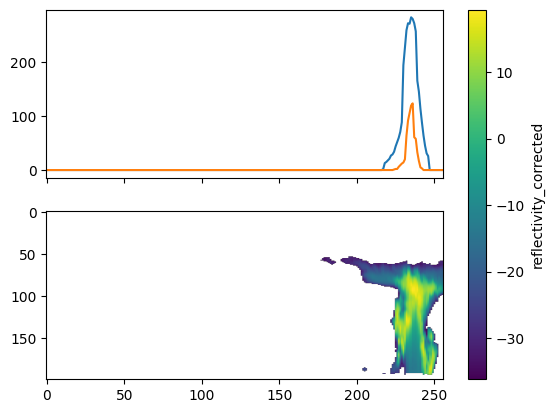

In [6]:
var = "reflectivity_corrected"
da = patch[var]
if da.dims == ("along_track", "height"):
    fig, axes = plt.subplots(2,1,sharex=True)

    line = axes[0].plot(patch.lightning_count_5.to_numpy())
    line = axes[0].plot(patch.lightning_count_2p5.to_numpy())
    image = axes[1].imshow(da.T, aspect="auto")#, cmap="RdBu_r", vmin=-5, vmax=5)
    
    plt.colorbar(image, ax=axes, orientation="vertical", label=f"{var}")

In [7]:
from goes2go import GOES

In [8]:
G = GOES(satellite=16, product="ABI-L2-CMIP", domain='F', channel=13)

In [9]:
files = G.nearesttime(patch.time.mean().values, download=False, return_as="filelist")

In [10]:
files

,file,product_mode,satellite,start,end,creation,product,mode_bands,mode,band
0,noaa-goes16/ABI-L2-CMIPF/2024/214/06/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 06:40:21,2024-08-01 06:49:52.900,2024-08-01 06:50:00.300,ABI-L2-CMIPF,M6C13,6,13


In [11]:
files.file[0]

'noaa-goes16/ABI-L2-CMIPF/2024/214/06/OR_ABI-L2-CMIPF-M6C13_G16_s20242140640210_e20242140649529_c20242140650003.nc'

In [12]:
import fsspec
fs = fsspec.filesystem('s3', anon=True)
fsspec_caching = {
    "cache_type": "blockcache",  # block cache stores blocks of fixed size and uses eviction using a LRU strategy.
    "block_size": 8 * 2**20,  # size in bytes per block, adjust depends on the file size but the recommended size is in the MB
}

In [13]:
goes_ds = xr.open_dataset(
    fs.open(files.file[0], **fsspec_caching), engine="h5netcdf"
)

In [14]:
goes_ds

<xarray.Dataset> Size: 235MB
Dimensions:                                           (y: 5424, x: 5424,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 22kB 0.1518...
  * x                                                 (x) float32 22kB -0.151...
    band_wavelength                                   (band) float32 4B ...
    band_id                                           (band) int32 4B ...
    t                                                 datetime64[ns] 8B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                band
Data variables: (12/35)
    CMI                                               (y, x) float32 118MB ...
    DQF                                               (y, x) float32 118MB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            int32 4B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    ...                                                ...
    focal_plane_temperature_threshold_exceeded_count  float64 8B ...
    maximum_focal_plane_temperature                   float32 4B ...
    focal_plane_temperature_threshold_increasing      float32 4B ...
    focal_plane_temperature_threshold_decreasing      float32 4B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    ...                        ...
    cdm_data_type:             Image
    time_coverage_start:       2024-08-01T06:40:21.0Z
    time_coverage_end:         2024-08-01T06:49:52.9Z
    timeline_id:               ABI Mode 6
    production_data_source:    Realtime
    id:                        10d0b413-fd79-417d-aa2b-fb33335615eb

In [15]:
from pyproj import Proj

In [16]:
def get_abi_proj(dataset: xr.Dataset) -> Proj:
    """
    Return a pyproj projection from the information contained within an ABI file
    """
    return Proj(
        proj="geos",
        h=dataset.goes_imager_projection.perspective_point_height,
        lon_0=dataset.goes_imager_projection.longitude_of_projection_origin,
        lat_0=dataset.goes_imager_projection.latitude_of_projection_origin,
        sweep=dataset.goes_imager_projection.sweep_angle_axis,
    )


In [17]:
def get_abi_x_y(
    lat: np.ndarray, lon: np.ndarray, dataset: xr.Dataset
) -> tuple[np.ndarray, np.ndarray]:
    """
    Get the x, y coordinates in the ABI projection for given latitudes and
        longitudes
    """
    p = get_abi_proj(dataset)
    x, y = p(lon, lat)
    return (
        x / dataset.goes_imager_projection.perspective_point_height,
        y / dataset.goes_imager_projection.perspective_point_height,
    )

In [18]:
patch_x, patch_y = get_abi_x_y(
    patch.latitude, patch.longitude, goes_ds
)

In [19]:
goes_ds.sel(
    x=slice(patch_x.mean()-128*5.5998564e-05, patch_x.mean()+128*5.5998564e-05), 
    y=slice(patch_y.mean()+128*5.5998564e-05, patch_y.mean()-128*5.5998564e-05)
)

<xarray.Dataset> Size: 527kB
Dimensions:                                           (y: 256, x: 256,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 1kB 0.05737...
  * x                                                 (x) float32 1kB 0.00288...
    band_wavelength                                   (band) float32 4B ...
    band_id                                           (band) int32 4B ...
    t                                                 datetime64[ns] 8B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                band
Data variables: (12/35)
    CMI                                               (y, x) float32 262kB ...
    DQF                                               (y, x) float32 262kB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            int32 4B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    ...                                                ...
    focal_plane_temperature_threshold_exceeded_count  float64 8B ...
    maximum_focal_plane_temperature                   float32 4B ...
    focal_plane_temperature_threshold_increasing      float32 4B ...
    focal_plane_temperature_threshold_decreasing      float32 4B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/29)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    ...                        ...
    cdm_data_type:             Image
    time_coverage_start:       2024-08-01T06:40:21.0Z
    time_coverage_end:         2024-08-01T06:49:52.9Z
    timeline_id:               ABI Mode 6
    production_data_source:    Realtime
    id:                        10d0b413-fd79-417d-aa2b-fb33335615eb

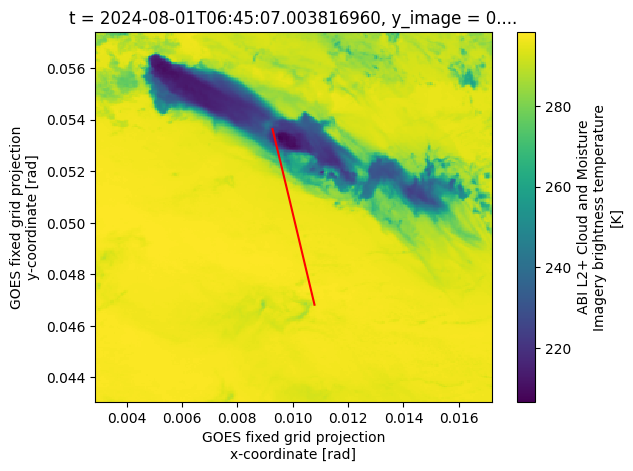

In [20]:
goes_ds.sel(
    x=slice(patch_x.mean()-128*5.5998564e-05, patch_x.mean()+128*5.5998564e-05), 
    y=slice(patch_y.mean()+128*5.5998564e-05, patch_y.mean()-128*5.5998564e-05)
).CMI.plot()
plt.plot(patch_x, patch_y, "r-")

In [21]:
patch_time = patch.time.mean().values

In [22]:
pd.Timestamp(patch_time - np.timedelta64(1, "h"))

Timestamp('2024-08-01 05:40:32.109414744')

In [23]:
files = G.timerange(
    pd.Timestamp(patch_time - np.timedelta64(185, "m")), 
    pd.Timestamp(patch_time + np.timedelta64(185, "m")), 
    download=False, 
    return_as="filelist"
)

In [24]:
files

,file,product_mode,satellite,start,end,creation,product,mode_bands,mode,band
0,noaa-goes16/ABI-L2-CMIPF/2024/214/03/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 03:40:20.700,2024-08-01 03:49:52.800,2024-08-01 03:49:59.600,ABI-L2-CMIPF,M6C13,6,13
1,noaa-goes16/ABI-L2-CMIPF/2024/214/03/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 03:50:20.700,2024-08-01 03:59:52.700,2024-08-01 04:00:00.400,ABI-L2-CMIPF,M6C13,6,13
2,noaa-goes16/ABI-L2-CMIPF/2024/214/04/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 04:00:20.700,2024-08-01 04:09:52.700,2024-08-01 04:10:00.400,ABI-L2-CMIPF,M6C13,6,13
3,noaa-goes16/ABI-L2-CMIPF/2024/214/04/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 04:10:20.700,2024-08-01 04:19:52.700,2024-08-01 04:20:00.200,ABI-L2-CMIPF,M6C13,6,13
4,noaa-goes16/ABI-L2-CMIPF/2024/214/04/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 04:20:20.700,2024-08-01 04:29:52.700,2024-08-01 04:29:59.800,ABI-L2-CMIPF,M6C13,6,13
5,noaa-goes16/ABI-L2-CMIPF/2024/214/04/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 04:30:20.700,2024-08-01 04:39:52.700,2024-08-01 04:40:00.200,ABI-L2-CMIPF,M6C13,6,13
6,noaa-goes16/ABI-L2-CMIPF/2024/214/04/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 04:40:20.700,2024-08-01 04:49:52.700,2024-08-01 04:50:00.400,ABI-L2-CMIPF,M6C13,6,13
7,noaa-goes16/ABI-L2-CMIPF/2024/214/04/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 04:50:20.700,2024-08-01 04:59:52.700,2024-08-01 05:00:00.800,ABI-L2-CMIPF,M6C13,6,13
8,noaa-goes16/ABI-L2-CMIPF/2024/214/05/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 05:00:20.700,2024-08-01 05:09:52.700,2024-08-01 05:10:00.200,ABI-L2-CMIPF,M6C13,6,13
9,noaa-goes16/ABI-L2-CMIPF/2024/214/05/OR_ABI-L2...,ABI-L2-CMIPF-M6C13,G16,2024-08-01 05:10:21.000,2024-08-01 05:19:52.900,2024-08-01 05:20:01.100,ABI-L2-CMIPF,M6C13,6,13


In [25]:
bt = []
for file in files.file:
    with fs.open(file, **fsspec_caching) as f, xr.open_dataset(f, engine="h5netcdf") as goes_ds:
        bt.append(goes_ds.sel(
            x=slice(patch_x.mean()-128*5.5998564e-05, patch_x.mean()+128*5.5998564e-05), 
            y=slice(patch_y.mean()+128*5.5998564e-05, patch_y.mean()-128*5.5998564e-05)
        ).CMI.load())


In [26]:
bt_da = xr.concat(bt, "t")

In [27]:
bt_da

<xarray.DataArray 'CMI' (t: 36, y: 256, x: 256)> Size: 9MB
array([[[285.10303, 285.71756, 284.54993, ..., 288.85165, 287.31534,
         287.4997 ],
        [287.1924 , 287.06952, 287.68405, ..., 290.08072, 288.42148,
         287.6226 ],
        [287.99133, 288.36005, 287.80695, ..., 289.65057, 285.6561 ,
         285.04156],
        ...,
        [295.48862, 295.30426, 295.55008, ..., 294.68973, 294.62827,
         294.7512 ],
        [296.1646 , 296.22607, 296.04172, ..., 294.62827, 294.62827,
         294.62827],
        [296.22607, 296.41043, 296.5948 , ..., 294.81265, 294.87408,
         294.62827]],

       [[293.76794, 294.56683, 295.36572, ..., 290.63382, 289.2204 ,
         285.10303],
        [294.01373, 294.4439 , 294.997  , ..., 288.72876, 287.6226 ,
         281.23145],
        [292.47742, 293.9523 , 294.997  , ..., 275.76212, 279.69513,
         269.3095 ],
...
        [296.22607, 296.2875 , 296.2875 , ..., 296.53333, 296.4719 ,
         296.4719 ],
        [295.73444, 295.98026, 296.04172, ..., 296.4719 , 296.53333,
         296.53333],
        [295.18137, 295.48862, 295.7959 , ..., 296.4719 , 296.53333,
         296.53333]],

       [[296.34897, 296.2875 , 296.41043, ..., 209.51543, 210.00705,
         211.23611],
        [296.34897, 296.2875 , 296.2875 , ..., 210.12997, 210.62158,
         212.09647],
        [296.34897, 296.41043, 296.2875 , ..., 211.42049, 211.72775,
         212.46518],
        ...,
        [295.48862, 295.36572, 295.36572, ..., 296.53333, 296.53333,
         296.41043],
        [295.2428 , 295.7959 , 295.73444, ..., 296.4719 , 296.4719 ,
         296.41043],
        [295.61154, 296.2875 , 296.1646 , ..., 296.4719 , 296.4719 ,
         296.4719 ]]], shape=(36, 256, 256), dtype=float32)
Coordinates:
  * t        (t) datetime64[ns] 288B 2024-08-01T03:45:06.791901056 ... 2024-0...
  * y        (y) float32 1kB 0.05737 0.05732 0.05726 ... 0.0432 0.04315 0.04309
  * x        (x) float32 1kB 0.002884 0.00294 0.002996 ... 0.01711 0.01716
    y_image  float32 4B 0.0
    x_image  float32 4B 0.0
Attributes:
    long_name:              ABI L2+ Cloud and Moisture Imagery brightness tem...
    standard_name:          toa_brightness_temperature
    sensor_band_bit_depth:  12
    valid_range:            [   0 4095]
    units:                  K
    resolution:             y: 0.000056 rad x: 0.000056 rad
    grid_mapping:           goes_imager_projection
    cell_methods:           t: point area: point
    ancillary_variables:    DQF

In [28]:
import hvplot.xarray

In [29]:
bt_da.drop(["x_image", "y_image"]).hvplot.image(
    x="x", y="y", groupby='t', width=600, widget_type='scrubber', widget_location='bottom', dynamic=False, 
    clim=(200, 300), 
)

/tmp/ipykernel_106/379531272.py:1: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  bt_da.drop(["x_image", "y_image"]).hvplot.image(


Column
    [0] HoloViews(HoloMap, height=300, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=600)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=35, width=550)

In [30]:
features = tobac.feature_detection_multithreshold(
    bt_da.rename(t="time"), dxy=2e3, threshold=[235, 220, 205], n_min_threshold=10, target="minimum",
    position_threshold="weighted_diff", 
)

In [31]:
features

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,time,timestr,y,x,y_image,x_image
0,0,4,7.376731,234.743239,29,220,1,2024-08-01 03:45:06.791901056,2024-08-01 03:45:06,0.056959,0.016030,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
1,0,5,33.735735,64.467522,151,220,2,2024-08-01 03:45:06.791901056,2024-08-01 03:45:06,0.055483,0.006494,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
2,0,6,38.922628,90.467190,13,220,3,2024-08-01 03:45:06.791901056,2024-08-01 03:45:06,0.055192,0.007950,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
3,0,7,48.368236,108.049181,94,220,4,2024-08-01 03:45:06.791901056,2024-08-01 03:45:06,0.054663,0.008935,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
4,1,5,103.735394,237.650732,20,235,5,2024-08-01 03:55:06.748551040,2024-08-01 03:55:06,0.051563,0.016192,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,35,8,110.738922,210.248479,142,235,204,2024-08-01 09:35:06.988183936,2024-08-01 09:35:06,0.051171,0.014658,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
204,35,10,15.437279,229.765166,1775,220,205,2024-08-01 09:35:06.988183936,2024-08-01 09:35:06,0.056508,0.015751,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
205,35,11,67.773662,241.775728,81,220,206,2024-08-01 09:35:06.988183936,2024-08-01 09:35:06,0.053577,0.016423,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...
206,35,12,87.120427,242.868105,159,220,207,2024-08-01 09:35:06.988183936,2024-08-01 09:35:06,0.052493,0.016485,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...


In [32]:
tracks = tobac.linking_trackpy(
    features, None, 600, 2e3, v_max=50, method_linking="predict", stubs=3, memory=2
)

Frame 35: 7 trajectories present.


In [33]:
mask, tracks = tobac.segmentation_2D(
    tracks, bt_da.rename(t="time"), 2e3, threshold=250, target="minimum",
    statistic=dict(bt_min=np.nanmin, bt_mean=np.nanmean)
)

In [34]:
mask

<xarray.DataArray 'segmentation_mask' (time: 36, y: 256, x: 256)> Size: 19MB
array([[[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
...
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ..., 198, 198, 198],
        [  0,   0,   0, ..., 198, 198, 198],
        [  0,   0,   0, ..., 198, 198, 198],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]],

       [[  0,   0,   0, ..., 205, 205, 205],
        [  0,   0,   0, ..., 205, 205, 205],
        [  0,   0,   0, ..., 205, 205, 205],
        ...,
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0]]], shape=(36, 256, 256))
Coordinates:
  * time     (time) datetime64[ns] 288B 2024-08-01T03:45:06.791901056 ... 202...
  * y        (y) float32 1kB 0.05737 0.05732 0.05726 ... 0.0432 0.04315 0.04309
  * x        (x) float32 1kB 0.002884 0.00294 0.002996 ... 0.01711 0.01716
    y_image  float32 4B 0.0
    x_image  float32 4B 0.0
Attributes:
    threshold:  250

In [35]:
mask.max()

<xarray.DataArray 'segmentation_mask' ()> Size: 8B
array(208)
Coordinates:
    y_image  float32 4B 0.0
    x_image  float32 4B 0.0
Attributes:
    threshold:  250

In [36]:
def convert_feature_mask_to_cells(
    features: pd.DataFrame, feature_mask: xr.DataArray, stubs: int | None = None
) -> xr.DataArray:
    """Relabels a feature mask provided by tobac.segmentation with the cell
    values provided by tobac.linking_trackpy

    Parameters
    ----------
    features : pd.DataFrame
        A feature dataframe with cell values provided by tobac.linking_trackpy
    feature_mask : xr.DataArray
        A feature mask from tobac.segmentation corresponding to the features in
        the feature dataframe input
    stubs : int, optional (default: None)
        The stub values used for unlinked cells in tobac.linking_trackpy. If
        None, the stub cells with be relabelled with the stub cell value in the
        feature dataframe. If a value is provided, the masked regions
        corresponding to stub cells with be removed from the output. Warning:
        the presence of stub cells may make it impossible to perfectly
        reconstruct the feature mask afterwards as any stub features will be
        removed.

    Returns
    -------
    xr.DataArray
        A mask of cell regions corresponding to the cells in the input dataframe

    Raises
    ------
    ValueError
        If the features input does not have a cell column
    ValueError
        If there are labels in the feature_mask that are not present in the
        features dataframe
    """
    if "cell" not in features.columns:
        raise ValueError(
            "`cell` column not found in features input, please perform tracking on this data before converting features to cells"
        )

    cell_mask = feature_mask.copy()

    cell_mapper = xr.DataArray(
        features.cell.copy(), dims=("feature",), coords=dict(feature=features.feature)
    )

    if stubs is not None:
        cell_mapper.data[features.cell == stubs] = 0

    wh_nonzero_label = np.flatnonzero(cell_mask)

    try:
        cell_mask.data.ravel()[wh_nonzero_label] = cell_mapper.loc[
            feature_mask.values.ravel()[wh_nonzero_label]
        ]
    except KeyError:
        raise ValueError(
            "Values in feature_mask are not present in features, please ensure that you are using the correct feature_mask for the tracked features, and that any filtering has been applied to both the mask and features"
        )

    cell_mask = cell_mask.assign_attrs(dict(units="cell"))

    return cell_mask

In [37]:
cell_mask = convert_feature_mask_to_cells(tracks, mask, stubs=-1)

In [38]:
cell_mask.max()

<xarray.DataArray 'segmentation_mask' ()> Size: 8B
array(35)
Coordinates:
    y_image  float32 4B 0.0
    x_image  float32 4B 0.0
Attributes:
    threshold:  250
    units:      cell

In [39]:
cell_mask.hvplot.image(
    x="x", y="y", groupby='time', width=600, widget_type='scrubber', widget_location='bottom', dynamic=False, 
    clim=(0, 39), 
)

Column
    [0] HoloViews(HoloMap, height=300, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=600)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=35, width=550)

In [40]:
cell_mask

<xarray.DataArray 'segmentation_mask' (time: 36, y: 256, x: 256)> Size: 19MB
array([[[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        ...,
...
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ..., 23, 23, 23],
        [ 0,  0,  0, ..., 23, 23, 23],
        [ 0,  0,  0, ..., 23, 23, 23],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]],

       [[ 0,  0,  0, ..., 23, 23, 23],
        [ 0,  0,  0, ..., 23, 23, 23],
        [ 0,  0,  0, ..., 23, 23, 23],
        ...,
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0],
        [ 0,  0,  0, ...,  0,  0,  0]]], shape=(36, 256, 256))
Coordinates:
  * time     (time) datetime64[ns] 288B 2024-08-01T03:45:06.791901056 ... 202...
  * y        (y) float32 1kB 0.05737 0.05732 0.05726 ... 0.0432 0.04315 0.04309
  * x        (x) float32 1kB 0.002884 0.00294 0.002996 ... 0.01711 0.01716
    y_image  float32 4B 0.0
    x_image  float32 4B 0.0
Attributes:
    threshold:  250
    units:      cell

In [41]:
cell_mask.sel(
    time=xr.DataArray(patch.time.values, dims="along_track"), 
    y=xr.DataArray(patch_y, dims="along_track"), 
    x=xr.DataArray(patch_x, dims="along_track"), 
    method="nearest"
)

<xarray.DataArray 'segmentation_mask' (along_track: 256)> Size: 2kB
array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18,
       18])
Coordinates:
    time     (along_track) datetime64[ns] 2kB 2024-08-01T06:45:07.003816960 ....
    y        (along_track) float32 1kB 0.04684 0.04684 ... 0.05362 0.05362
    x        (along_track) float32 1kB 0.01078 0.01078 ... 0.009268 0.009268
    y_image  float32 4B 0.0
    x_image  float32 4B 0.0
Dimensions without coordinates: along_track
Attributes:
    threshold:  250
    units:      cell

In [42]:
track_18 = tracks[tracks.cell==18]

In [43]:
track_18 = track_18.set_index("time")

In [44]:
track_18

,frame,idx,hdim_1,hdim_2,num,threshold_value,feature,timestr,y,x,y_image,x_image,cell,time_cell,ncells,bt_min,bt_mean
time,,,,,,,,,,,,,,,,,
2024-08-01 06:05:07.006275968,14,7,69.859935,125.994519,32,220,84,2024-08-01 06:05:07,0.053460,0.009940,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:00:00,145,209.515427,229.290253
2024-08-01 06:15:06.997347968,15,6,70.770175,125.190276,78,220,88,2024-08-01 06:15:06,0.053409,0.009895,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:09:59.991072,278,206.565674,227.406082
2024-08-01 06:25:06.988850048,16,6,71.878714,123.783762,131,220,92,2024-08-01 06:25:06,0.053347,0.009816,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:19:59.982574080,414,199.744354,225.142807
2024-08-01 06:35:06.976211968,17,5,73.474577,124.129468,194,220,97,2024-08-01 06:35:06,0.053257,0.009835,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:29:59.969936,525,207.057297,223.913879
2024-08-01 06:45:07.003816960,18,9,74.785370,124.765961,238,220,102,2024-08-01 06:45:07,0.053184,0.009871,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:39:59.997540992,748,206.627121,225.517136
2024-08-01 06:55:06.997169024,19,9,76.481504,125.420736,247,220,107,2024-08-01 06:55:06,0.053089,0.009908,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:49:59.990893056,1591,208.65509,229.737946
2024-08-01 07:05:06.985232896,20,10,78.761235,126.270549,256,220,111,2024-08-01 07:05:06,0.052961,0.009955,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 00:59:59.978956928,1695,208.593628,230.34581
2024-08-01 07:15:06.978902016,21,15,81.147517,128.060468,243,220,120,2024-08-01 07:15:06,0.052828,0.010055,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 01:09:59.972626048,1614,210.314331,230.244537
2024-08-01 07:25:06.986771968,22,13,83.688451,130.572550,218,220,126,2024-08-01 07:25:06,0.052685,0.010196,<xarray.DataArray 'y_image' ()> Size: 4B\narra...,<xarray.DataArray 'x_image' ()> Size: 4B\narra...,18,0 days 01:19:59.980496,1649,212.649551,230.874924


In [45]:
patch["cell"] = cell_mask.sel(
    time=xr.DataArray(patch.time.values, dims="along_track"), 
    y=xr.DataArray(patch_y, dims="along_track"), 
    x=xr.DataArray(patch_x, dims="along_track"), 
    method="nearest"
)

In [46]:
patch = patch.assign_coords(height=patch.height[::-1])

In [47]:
min_mask, max_mask = patch.along_track[np.where(patch.cell==18)].min(), patch.along_track[np.where(patch.cell==18)].max()

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_106/3220838180.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Area [$\mathrm{km^2}$]", color="C1")


Text(0, 0.5, 'Area [$\\mathrm{km^2}$]')

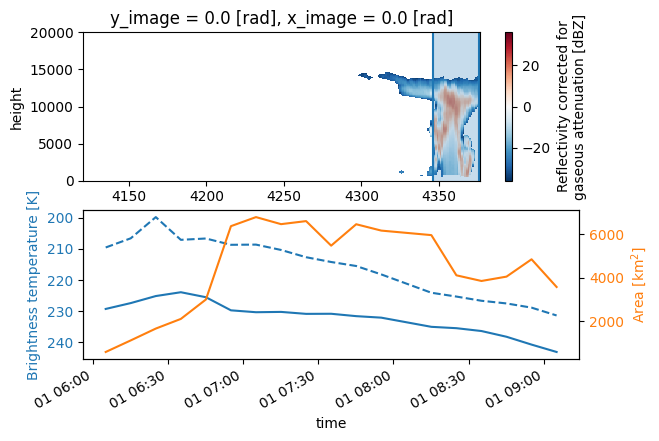

In [48]:
fig, (ax, ax1) = plt.subplots(2, 1)

patch.reflectivity_corrected.T.plot(ax=ax)
# patch.cell.plot(ax=ax)
ax.fill_betweenx([0,2e4], [min_mask,min_mask], [max_mask, max_mask], alpha=0.25)
ax.axvline(min_mask, color="C0")
ax.axvline(max_mask, color="C0")


track_18.bt_min.plot(color="C0", ls="--")
track_18.bt_mean.plot(color="C0")
ax1.tick_params(axis='y', labelcolor="C0")
ax1.invert_yaxis()

ax2 = ax1.twinx()
(track_18.ncells * 4).plot(color="C1")
ax2.tick_params(axis='y', labelcolor="C1")

ax1.set_ylabel("Brightness temperature [K]", color="C0")
ax2.set_ylabel("Area [$\mathrm{km^2}$]", color="C1")

In [49]:
GLM = GOES(satellite=16, product="GLM")

In [50]:
track_18.index.min()

Timestamp('2024-08-01 06:05:07.006275968')

In [51]:
glm_files = GLM.timerange(
    track_18.index.min(), 
    track_18.index.max(), 
    download=False, 
    return_as="filelist"
)

In [52]:
len(glm_files)

539

In [53]:
x_min, x_max = bt_da.x.min().item(), bt_da.x.max().item()
y_min, y_max = bt_da.y.min().item(), bt_da.y.max().item()

glm_datasets = []
for file in glm_files.file:
    with fs.open(file, **fsspec_caching) as f, xr.open_dataset(f, engine="h5netcdf") as glm_ds:
        glm_ds = glm_ds[[var for var in glm_ds if glm_ds[var].dims==("number_of_flashes",)]]
        flash_x, flash_y = get_abi_x_y(glm_ds.flash_lat, glm_ds.flash_lon, goes_ds)
        wh_coloc_flash = np.logical_and.reduce(
            [
                flash_x >= x_min, 
                flash_x <= x_max, 
                flash_y >= y_min, 
                flash_y <= y_max, 
            ]
        )
        glm_ds = glm_ds.isel(number_of_flashes=wh_coloc_flash)
        glm_datasets.append(glm_ds.load())
        

In [54]:
len(glm_datasets)

539

In [55]:
glm_datasets[0]

<xarray.Dataset> Size: 352B
Dimensions:                                 (number_of_flashes: 6)
Coordinates:
    flash_id                                (number_of_flashes) uint16 12B 53...
    flash_time_offset_of_first_event        (number_of_flashes) datetime64[ns] 48B ...
    flash_time_offset_of_last_event         (number_of_flashes) datetime64[ns] 48B ...
    flash_lat                               (number_of_flashes) float32 24B 1...
    flash_lon                               (number_of_flashes) float32 24B -...
    product_time                            datetime64[ns] 8B 2024-08-01T06:0...
    lightning_wavelength                    float32 4B 777.4
    group_time_threshold                    float32 4B 0.0
    flash_time_threshold                    float32 4B 3.33
    lat_field_of_view                       float32 4B 0.0
    lon_field_of_view                       float32 4B -75.0
Dimensions without coordinates: number_of_flashes
Data variables:
    flash_frame_time_offset_of_first_event  (number_of_flashes) datetime64[ns] 48B ...
    flash_frame_time_offset_of_last_event   (number_of_flashes) datetime64[ns] 48B ...
    flash_area                              (number_of_flashes) float32 24B 2...
    flash_energy                            (number_of_flashes) float32 24B 1...
    flash_quality_flag                      (number_of_flashes) float32 24B 0...
Attributes: (12/29)
    production_site:           WCDAS
    featureType:               point
    dataset_name:              OR_GLM-L2-LCFA_G16_s20242140605200_e2024214060...
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    institution:               DOC/NOAA/NESDIS> U.S. Department of Commerce, ...
    ...                        ...
    time_coverage_start:       2024-08-01T06:05:20.0Z
    time_coverage_end:         2024-08-01T06:05:40.0Z
    production_data_source:    Realtime
    production_environment:    OE
    LUT_Filenames:             GLM_CALINR_AllFilters(FM1E_CDRL79RevK_DO_09_00...
    id:                        6b56a976-67b2-4834-af03-1268e3c748e0

In [56]:
glm_all = xr.concat(glm_datasets, dim="number_of_flashes")

/tmp/ipykernel_106/1147011016.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  glm_all = xr.concat(glm_datasets, dim="number_of_flashes")


In [57]:
flash_x, flash_y = get_abi_x_y(glm_all.flash_lat, glm_all.flash_lon, goes_ds)

In [58]:
glm_all.product_time

<xarray.DataArray 'product_time' (number_of_flashes: 1229)> Size: 10kB
array(['2024-08-01T06:05:20.000000000', '2024-08-01T06:05:20.000000000',
       '2024-08-01T06:05:20.000000000', ...,
       '2024-08-01T09:04:20.000000000', '2024-08-01T09:04:40.000000000',
       '2024-08-01T09:04:40.000000000'],
      shape=(1229,), dtype='datetime64[ns]')
Coordinates:
    flash_id                          (number_of_flashes) uint16 2kB 53260 .....
    flash_time_offset_of_first_event  (number_of_flashes) datetime64[ns] 10kB ...
    flash_time_offset_of_last_event   (number_of_flashes) datetime64[ns] 10kB ...
    flash_lat                         (number_of_flashes) float32 5kB 18.62 ....
    flash_lon                         (number_of_flashes) float32 5kB -73.21 ...
    product_time                      (number_of_flashes) datetime64[ns] 10kB ...
    lightning_wavelength              float32 4B 777.4
    group_time_threshold              float32 4B 0.0
    flash_time_threshold              float32 4B 3.33
    lat_field_of_view                 float32 4B 0.0
    lon_field_of_view                 float32 4B -75.0
Dimensions without coordinates: number_of_flashes
Attributes:
    long_name:      start time of observations associated with product
    standard_name:  time
    axis:           T
    bounds:         product_time_bounds

In [60]:
flash_cell_mask = cell_mask.sel(
    time=glm_all.product_time,
    y=xr.DataArray(flash_y, dims="number_of_flashes"), 
    x=xr.DataArray(flash_x, dims="number_of_flashes"), 
    method="nearest"
)

In [62]:
glm_18 = glm_all.sel(number_of_flashes=flash_cell_mask==18)

In [63]:
glm_18

<xarray.Dataset> Size: 17kB
Dimensions:                                 (number_of_flashes: 215)
Coordinates: (12/16)
    flash_id                                (number_of_flashes) uint16 430B 5...
    flash_time_offset_of_first_event        (number_of_flashes) datetime64[ns] 2kB ...
    flash_time_offset_of_last_event         (number_of_flashes) datetime64[ns] 2kB ...
    flash_lat                               (number_of_flashes) float32 860B ...
    flash_lon                               (number_of_flashes) float32 860B ...
    product_time                            (number_of_flashes) datetime64[ns] 2kB ...
    ...                                      ...
    group_time_threshold                    float32 4B 0.0
    flash_time_threshold                    float32 4B 3.33
    lat_field_of_view                       float32 4B 0.0
    lon_field_of_view                       float32 4B -75.0
    y_image                                 float32 4B 0.0
    x_image                                 float32 4B 0.0
Dimensions without coordinates: number_of_flashes
Data variables:
    flash_frame_time_offset_of_first_event  (number_of_flashes) datetime64[ns] 2kB ...
    flash_frame_time_offset_of_last_event   (number_of_flashes) datetime64[ns] 2kB ...
    flash_area                              (number_of_flashes) float32 860B ...
    flash_energy                            (number_of_flashes) float32 860B ...
    flash_quality_flag                      (number_of_flashes) float32 860B ...
Attributes: (12/29)
    production_site:           WCDAS
    featureType:               point
    dataset_name:              OR_GLM-L2-LCFA_G16_s20242140605200_e2024214060...
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    institution:               DOC/NOAA/NESDIS> U.S. Department of Commerce, ...
    ...                        ...
    time_coverage_start:       2024-08-01T06:05:20.0Z
    time_coverage_end:         2024-08-01T06:05:40.0Z
    production_data_source:    Realtime
    production_environment:    OE
    LUT_Filenames:             GLM_CALINR_AllFilters(FM1E_CDRL79RevK_DO_09_00...
    id:                        6b56a976-67b2-4834-af03-1268e3c748e0

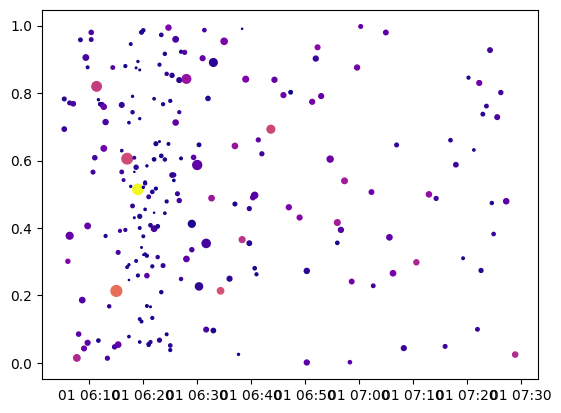

In [64]:
plt.scatter(
    glm_18.product_time,
    np.random.rand(glm_18.number_of_flashes.size), 
    c=glm_18.flash_energy,
    s=glm_18.flash_area*1e-8,
    cmap="plasma"
)

In [68]:
patch_time

np.datetime64('2024-08-01T06:40:32.109414744')

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_106/639040872.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Area [$\mathrm{km^2}$]", color="C1")


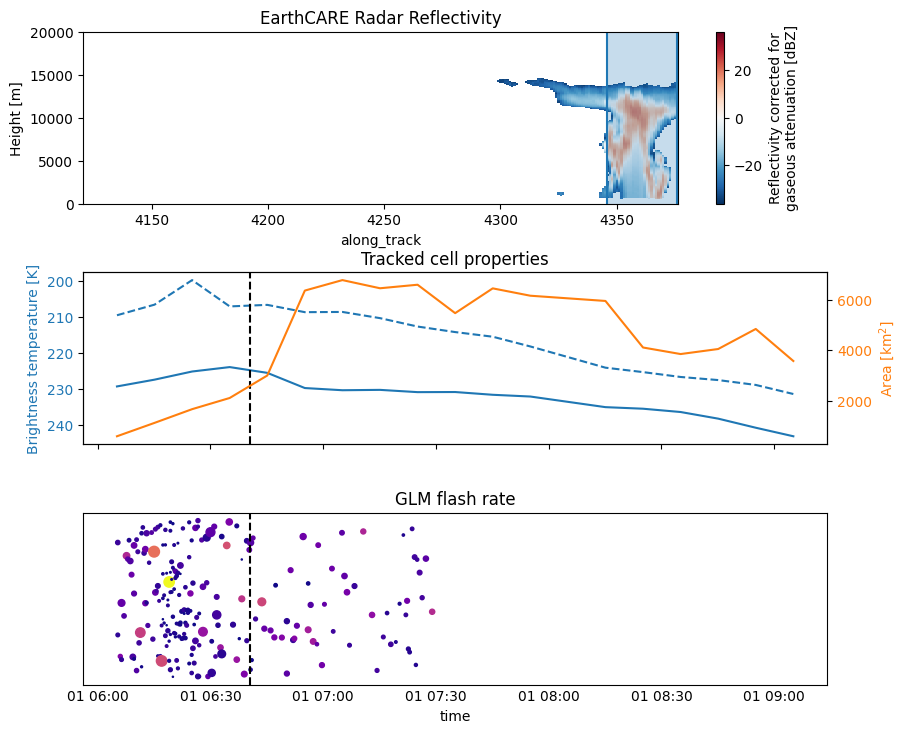

In [87]:
fig, (ax, ax1, ax3) = plt.subplots(3, 1, figsize=(9.6,9.6))

patch.reflectivity_corrected.T.plot(ax=ax)
# patch.cell.plot(ax=ax)
ax.fill_betweenx([0,2e4], [min_mask,min_mask], [max_mask, max_mask], alpha=0.25)
ax.axvline(min_mask, color="C0")
ax.axvline(max_mask, color="C0")

ax.set_title("EarthCARE Radar Reflectivity")
ax.set_ylabel("Height [m]")

track_18.bt_min.plot(ax=ax1, color="C0", ls="--")
track_18.bt_mean.plot(ax=ax1, color="C0")
ax1.tick_params(axis='y', labelcolor="C0")
ax1.invert_yaxis()

ax2 = ax1.twinx()
(track_18.ncells * 4).plot(ax=ax2, color="C1")
ax2.tick_params(axis='y', labelcolor="C1")
ax1.axvline(patch_time, color="k", ls="--")

ax1.set_ylabel("Brightness temperature [K]", color="C0")
ax2.set_ylabel("Area [$\mathrm{km^2}$]", color="C1")
ax1.tick_params(labelbottom=False)
ax1.set_xlabel("")
ax1.set_title("Tracked cell properties")

ax3.scatter(
    glm_18.product_time,
    np.random.rand(glm_18.number_of_flashes.size), 
    c=glm_18.flash_energy,
    s=glm_18.flash_area*1e-8,
    cmap="plasma"
)
ax3.axvline(patch_time, color="k", ls="--")

ax3.sharex(ax1)
ax3.tick_params(labelleft=False, length=0)
ax3.set_xlabel("time")
ax3.set_title("GLM flash rate")

plt.subplots_adjust(hspace=0.4)

In [89]:
from scipy.ndimage import gaussian_filter

In [131]:
glm_18.flash_area.groupby(glm_18.product_time).count().size

133

In [132]:
scale = gaussian_filter(
    glm_18.flash_area.groupby(glm_18.product_time).sum(), 1
)

In [133]:
scale = xr.DataArray(scale, coords=dict(time=np.unique(glm_18.product_time)), dims="time")

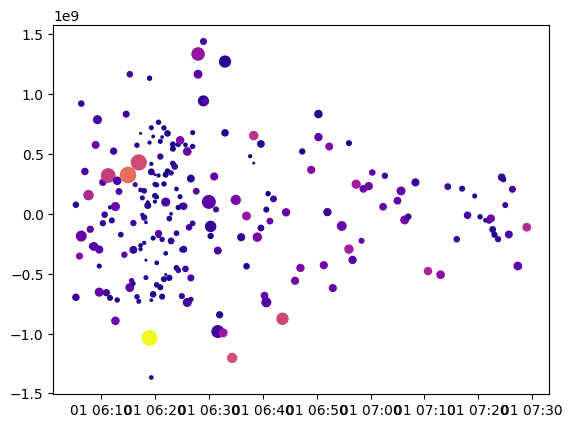

In [134]:
plt.scatter(
    glm_18.product_time,
    (np.random.rand(glm_18.number_of_flashes.size)-0.5)*scale.sel(time=glm_18.product_time), 
    c=glm_18.flash_energy,
    s=glm_18.flash_area*1e-8*2,
    cmap="plasma"
)

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_106/3043445601.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel("Area [$\mathrm{km^2}$]", color="C1")


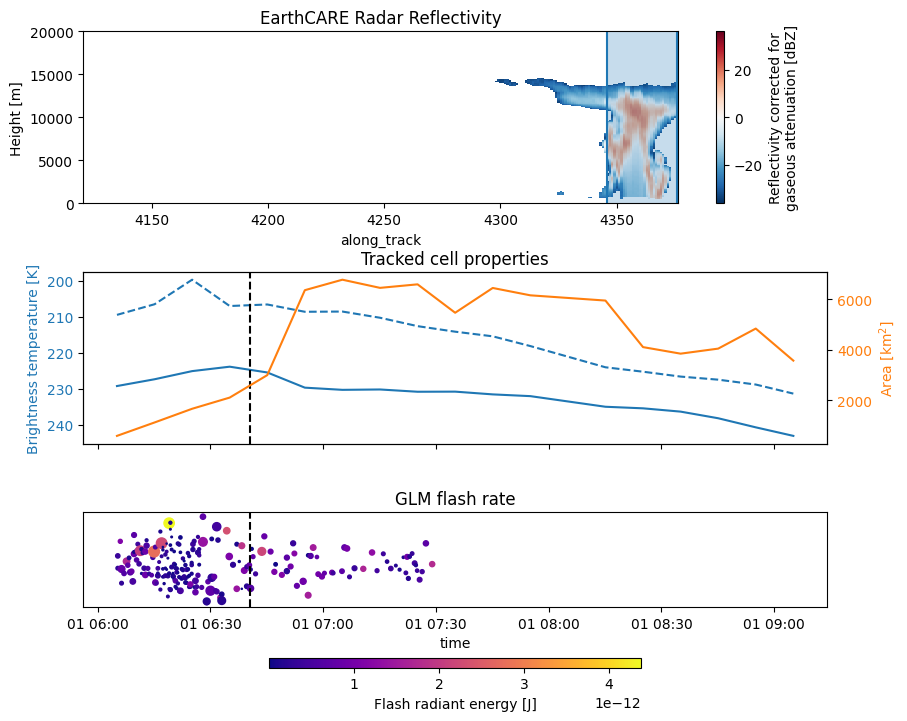

In [135]:
fig, (ax, ax1, ax3) = plt.subplots(3, 1, figsize=(9.6,9.6))

patch.reflectivity_corrected.T.plot(ax=ax)
# patch.cell.plot(ax=ax)
ax.fill_betweenx([0,2e4], [min_mask,min_mask], [max_mask, max_mask], alpha=0.25)
ax.axvline(min_mask, color="C0")
ax.axvline(max_mask, color="C0")

ax.set_title("EarthCARE Radar Reflectivity")
ax.set_ylabel("Height [m]")

track_18.bt_min.plot(ax=ax1, color="C0", ls="--")
track_18.bt_mean.plot(ax=ax1, color="C0")
ax1.tick_params(axis='y', labelcolor="C0")
ax1.invert_yaxis()

ax2 = ax1.twinx()
(track_18.ncells * 4).plot(ax=ax2, color="C1")
ax2.tick_params(axis='y', labelcolor="C1")
ax1.axvline(patch_time, color="k", ls="--")

ax1.set_ylabel("Brightness temperature [K]", color="C0")
ax2.set_ylabel("Area [$\mathrm{km^2}$]", color="C1")
ax1.tick_params(labelbottom=False)
ax1.set_xlabel("")
ax1.set_title("Tracked cell properties")

points= ax3.scatter(
    glm_18.product_time,
    (np.random.rand(glm_18.number_of_flashes.size)-0.5)*scale.sel(time=glm_18.product_time), 
    c=glm_18.flash_energy,
    s=glm_18.flash_area*1e-8,
    cmap="plasma"
)
ax3.axvline(patch_time, color="k", ls="--")

ax3.sharex(ax1)
ax3.tick_params(labelleft=False, length=0, axis="y")
ax3.set_xlabel("time")
ax3.set_title("GLM flash rate")

plt.colorbar(points, ax=ax3, label="Flash radiant energy [J]", orientation="horizontal", aspect=40, shrink=0.5, pad=0.3)

plt.subplots_adjust(hspace=0.4)